In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
from sklearn import svm
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score, make_scorer

from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import VotingClassifier


from sklearn.experimental import enable_halving_search_cv  
from sklearn.model_selection import HalvingRandomSearchCV




## Uitleg van alle kolommen

| Kolom                  | Uitleg                                     | Of we de kolom verwijderen en waarom
| ----------------------- | ------------------------------------------ |------------------------------------
| id                     | ID nummer van de patiënte                  |Ja, omdat dit niet nodig is voor de voorspelling
| age                    | Leeftijd van de patiënte                   |Nee
| hypertension           | Of de patiënte Hypertensie (te hoge bloeddruk) heeft           |Nee
| heart_disease          | Of de patiënte Hartziekte heeft            |Nee
| avg_glucose_level      | Gemiddelde glucosewaarde van de patiënte (mg/dl)  |Nee
| bmi                    | Body Mass Index van de patiënte            |Nee
| gender_Female          | Of de patiënte een vrouw is                |Nee
| gender_Male            | Of de patiënte een Man is                  |Nee
| gender_Other           | Of de patiënte een overig is               |Ja, omdat je met on-hot-encoding deze waarde al kan voorspellen want anders krijgt je coliniariteit. dit voorkomt de “dummy trap” 
| ever_married_No        | Of de patiënte nooit getrouwd is           |Ja, omdat je met on-hot-encoding deze waarde al kan voorspellen want anders krijgt je coliniariteit
| ever_married_Yes       | Of de patiënte ooit getrouwd               |Nee
| work_type_Govt_job     | Of de patiënte een overheidsbaan heeft / heeft gehad        |Nee
| work_type_Never_worked | Of de patiënte nooit gewerkt heeft / heeft gehad           |Nee
| work_type_Private      | Of de patiënte een privé baan heeft / heeft gehad               |Nee
| work_type_Self-employed| Of de patiënte een zzper is / is geweest         |Nee
| work_type_children     | Of de patiënte een kind is / nog niet gewerkt              |Ja, mdat je met on-hot-encoding deze waarde al kan voorspellen want anders krijgt je coliniariteit
| Residence_type_Rural   | Of de patiënte niet in een stad woont (ja/nee)             |Nee
| Residence_type_Urban   | Of de patiënte stedelijk woont             |Ja, mdat je met on-hot-encoding deze waarde al kan voorspellen want anders krijgt je coliniariteit
| smoking_status_formerly smoked | Of de patiënte vroeger heeft gerookt     |Nee
| smoking_status_never smoked |Of de patiënte nooit heeft gerookt          |Nee
| smoking_status_smokes  | Of de patiënte rookt              |Ja, mdat je met on-hot-encoding deze waarde al kan voorspellen want anders krijgt je coliniariteit
| stroke                 | Of de patiënte een herseninfarct heeft gehad |Nee/Ja, We gaan hem verwijderen uit de train set omdat dit de voorspellende waarde is dus krijgt hij zijn eigen dataset

  

# Opdracht 1: Exploratieve Data Analyse

#### Opdracht 1.1 / 1.2
- Beschrijf in hoeverre de data voldoet aan de minimale vereisten voor Machine Learning met Scikit Learn. Indien nodig, maak de noodzakelijke aanpassingen.
- Toon de datatypes en basisstatistieken van iedere kolom.

In [133]:
# data inlezen
df = pd.read_csv('train.csv')
display(df)


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,52709,30.0,0,0,63.60,33.3,False,True,False,True,...,False,True,False,False,True,False,False,False,True,0
1,72295,75.0,1,0,215.17,48.0,True,False,False,False,...,False,False,True,False,True,False,False,True,False,0
2,26451,15.0,0,0,135.22,19.0,False,True,False,True,...,False,True,False,False,True,False,False,True,False,0
3,65210,47.0,0,0,64.89,28.2,False,True,False,False,...,False,False,True,False,False,True,False,True,False,0
4,69299,49.0,0,0,222.34,28.8,False,True,False,False,...,False,False,True,False,True,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33545,71911,9.0,0,0,109.80,14.5,False,True,False,True,...,False,False,False,True,True,False,False,False,False,0
33546,19648,47.0,0,0,88.61,30.8,True,False,False,False,...,False,True,False,False,False,True,False,False,False,0
33547,35550,3.0,0,0,89.68,16.2,True,False,False,True,...,False,False,False,True,True,False,False,False,False,0
33548,65453,56.0,1,0,82.44,27.8,True,False,False,False,...,False,False,False,False,False,True,False,False,True,0


In [134]:
# datatype en basisstatistieken
display(df.info())
display(df.describe())

# missende waarde zoeken
missen = df.isna().sum()
print(missen)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33550 entries, 0 to 33549
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              33550 non-null  int64  
 1   age                             33550 non-null  float64
 2   hypertension                    33550 non-null  int64  
 3   heart_disease                   33550 non-null  int64  
 4   avg_glucose_level               33550 non-null  float64
 5   bmi                             33550 non-null  float64
 6   gender_Female                   33550 non-null  bool   
 7   gender_Male                     33550 non-null  bool   
 8   gender_Other                    33550 non-null  bool   
 9   ever_married_No                 33550 non-null  bool   
 10  ever_married_Yes                33550 non-null  bool   
 11  work_type_Govt_job              33550 non-null  bool   
 12  work_type_Never_worked          

None

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000
mean,36746.393353,41.815312,0.088137,0.043040,103.587081,28.601216,0.015410
std,20906.519131,22.477423,0.283498,0.202951,42.127396,7.782248,0.123178
min,1.000000,0.080000,0.000000,0.000000,55.010000,10.100000,0.000000
25%,18763.250000,24.000000,0.000000,0.000000,77.460000,23.300000,0.000000
50%,36862.000000,43.000000,0.000000,0.000000,91.320000,27.700000,0.000000
75%,54757.500000,59.000000,0.000000,0.000000,111.437500,32.800000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,281.590000,97.600000,1.000000


id                                0
age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
gender_Female                     0
gender_Male                       0
gender_Other                      0
ever_married_No                   0
ever_married_Yes                  0
work_type_Govt_job                0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Rural              0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
stroke                            0
dtype: int64


In [135]:
#OOP model aangemaakt en in de init functie al meteen de onnodige kolomen verwijderd
class Modelleren:
    """
    Klasse voor het voorbereiden, splitsen en modelleren van een dataset met behulp van GridSearchCV.

    Parameters:
    -----------
    dataframe : pandas.DataFrame
        De originele dataset.
    coloms_del : list, optional
        Lijst van kolomnamen die verwijderd moeten worden uit de dataset (default is een lege lijst).
    """

    def __init__(self, dataframe, coloms_del=[]):
        """
        Initialiseert de Modelleren klasse door opgegeven kolommen te verwijderen uit de dataset.

        Parameters:
        -----------
        dataframe : pandas.DataFrame
            De originele dataset.
        coloms_del : list
            Kolommen die verwijderd moeten worden.
        """
        self.colms_del = coloms_del
        self.df = dataframe.drop(self.colms_del, axis=1)

    def split_data(self, target):
        """
        Splitst de dataset in features (X) en target (y).

        Parameters:
        -----------
        target : str
            De naam van de target kolom.
        """
        self.X = self.df.drop(columns=[target])
        self.y = self.df[target]

    def train_test(self, size, state):
        """
        Splitst de data in trainings- en testsets.

        Parameters:
        -----------
        size : float
            Het percentage van de data dat gebruikt wordt als testset (tussen 0 en 1).
        state : int
            Random seed voor reproduceerbaarheid.
        """
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=size, random_state=state)

    def grid(self, pipe, param, cv_grid, scoring='accuracy', jobs=1):
        """
        Voert een GridSearchCV uit op de trainingsdata en slaat de voorspellingen op.

        Parameters:
        -----------
        pipe : sklearn.pipeline.Pipeline
            De machine learning pipeline die getuned moet worden.
        param : dict
            Parametergrid voor hyperparameter tuning.
        cv_grid : int
            Aantal cross-validation folds.
        scoring : str, optional
            Scoring metric voor evaluatie (default is 'accuracy').
        jobs : int, optional
            Aantal parallelle processen (default is 1).
        """
        self.grids = GridSearchCV(
            pipe,
            param_grid=param,
            cv=cv_grid,
            scoring=scoring,
            n_jobs=jobs)

        self.grids.fit(self.X_train, self.y_train)
        self.y_pred = self.grids.predict(self.X_test)
        self.y_proba = self.grids.predict_proba(self.X_test)[:, 1]


model = Modelleren(df,['id','gender_Other','ever_married_No','work_type_children','Residence_type_Urban','smoking_status_smokes'] )
display(model.df)


,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,Residence_type_Rural,smoking_status_formerly smoked,smoking_status_never smoked,stroke
0,30.0,0,0,63.60,33.3,False,True,False,False,False,True,False,True,False,False,0
1,75.0,1,0,215.17,48.0,True,False,True,False,False,False,True,True,False,True,0
2,15.0,0,0,135.22,19.0,False,True,False,False,False,True,False,True,False,True,0
3,47.0,0,0,64.89,28.2,False,True,True,False,False,False,True,False,False,True,0
4,49.0,0,0,222.34,28.8,False,True,True,False,False,False,True,True,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33545,9.0,0,0,109.80,14.5,False,True,False,False,False,False,False,True,False,False,0
33546,47.0,0,0,88.61,30.8,True,False,True,False,False,True,False,False,False,False,0
33547,3.0,0,0,89.68,16.2,True,False,False,False,False,False,False,True,False,False,0
33548,56.0,1,0,82.44,27.8,True,False,True,True,False,False,False,False,False,False,0


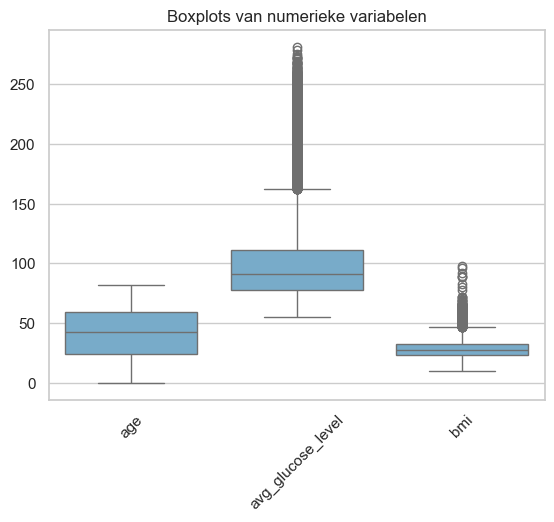

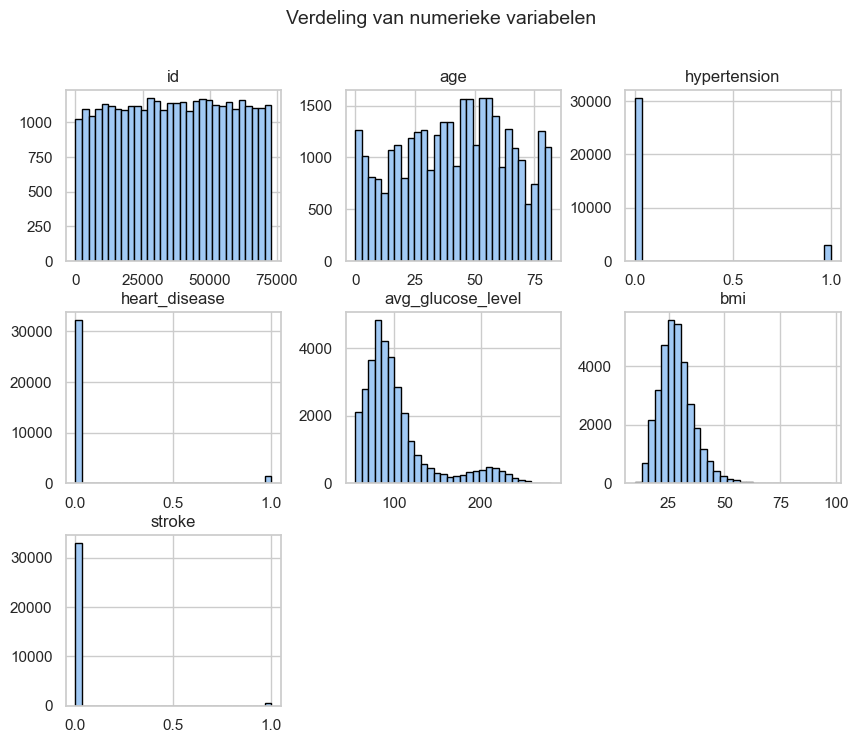

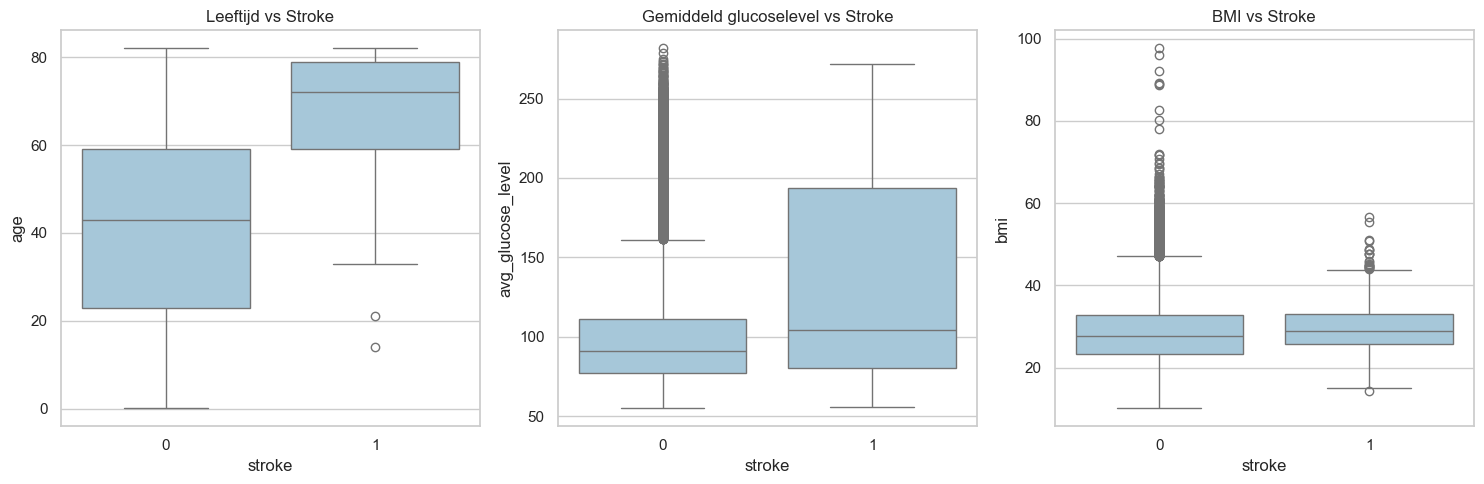

In [136]:
# Functie voor algemene boxplots (zonder target, voor verdeling en outliers)
def plot_boxplot(df, columns):
    """
    Maakt boxplots voor de opgegeven kolommen van een DataFrame.
    Parameters:
    df: DataFrame
    columns: lijst met kolomnamen waarvoor je boxplots wilt maken.
    """
    sns.boxplot(data=df[columns], color='#6baed6')  # neutrale kleur (geen clutter)
    plt.title("Boxplots van numerieke variabelen")
    plt.xticks(rotation=45)
    plt.show()

#  Uitvoeren van algemene boxplots (controle op outliers) 
plot_boxplot(df, ['age', 'avg_glucose_level', 'bmi'])

#  Histogram voor verdeling van numerieke data 
df_num = df.select_dtypes(include='number')
df_num.hist(bins=30, figsize=(10, 8), edgecolor="black")
plt.suptitle("Verdeling van numerieke variabelen", fontsize=14)
plt.show()

#  Boxplots per variabele tegenover target 'stroke'
# Eerst NaN waarden verwijderen om fouten te voorkomen
df = df.dropna(subset=['age', 'avg_glucose_level', 'bmi', 'stroke'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x='stroke', y='age', data=df, ax=axes[0], color='#9ecae1')
axes[0].set_title('Leeftijd vs Stroke')

sns.boxplot(x='stroke', y='avg_glucose_level', data=df, ax=axes[1], color='#9ecae1')
axes[1].set_title('Gemiddeld glucoselevel vs Stroke')

sns.boxplot(x='stroke', y='bmi', data=df, ax=axes[2], color='#9ecae1')
axes[2].set_title('BMI vs Stroke')

plt.tight_layout()
plt.show()

In [137]:
#alleen de waardes houden waar de bmi kleiner is dan 70
model.df = model.df[model.df["bmi"]< 70]


### Toelichting

*   Om het model te trainen moet de dataset aan bepaalde voorwaarden voldoen: de data moet een numeriek formaat hebben, er mogen geen missende waarden in zitten, er mogen geen uitschieters (outliers) zijn, en de data moet opgeslagen zijn in een pandas DataFrame of NumPy array.

*   In de dataset zitten geen missende waarden. We hebben een boxplot gemaakt voor de kolommen `age`, `avg_glucose_level` en `bmi` om te controleren op uitschieters, en daarnaast een histogram om te bekijken of de data normaal verdeeld is. Uit de boxplot blijkt dat er enkele uitschieters aanwezig zijn in de kolom `bmi`.

*   Om de relatie tussen de features en de targetvariabele `stroke` te onderzoeken, hebben we aparte boxplots gemaakt waarin de verdeling van `age`, `avg_glucose_level` en `bmi` wordt vergeleken tussen personen met en zonder beroerte (`stroke = 1` of `0`).  
    Hieruit blijkt dat mensen die een beroerte hebben gehad gemiddeld ouder zijn en een iets hoger gemiddeld glucosegehalte hebben. Bij BMI is er geen duidelijk visueel verschil zichtbaar tussen de twee groepen.  
    Deze analyse helpt ons te begrijpen welke kenmerken mogelijk verband houden met het risico op een beroerte.

*   Uit de literatuur blijkt dat glucosewaarden van ≥ 200 mg/dL (wat overeenkomt met ≥ 11,1 mmol/L) in de context van een 2-uur OGTT vaak als grens voor diabetes worden gehanteerd (Zubair & Launico, 2025b). Daarom nemen we in de training van ons model ook die hoge glucosewaarden mee.  
    **Bron:** Zubair, M., & Launico, M. V. (2025b, september 15). _Glucose tolerance test._ StatPearls - NCBI Bookshelf. [https://www.ncbi.nlm.nih.gov/books/NBK532915/](https://www.ncbi.nlm.nih.gov/books/NBK532915/)

*   Ook zijn er casussen bekend waarbij de BMI extreem hoog is (bijv. ≥ 70 kg/m²) (Kabir et al., 2020). Omdat zulke zeer hoge BMI-waarden zeldzaam zijn en de dataverdeling kunnen verstoren, kiezen we er in dit project voor om alle BMI-waarden boven de 70 te filteren.  
    Het gaat om ongeveer 30 rijen, relatief weinig, zodat we nog steeds voldoende gegevens overhouden om een betrouwbaar model te bouwen.  
    **Bron:** Kabir, S., Hossain, A. T., Shimmi, S. C., & Jie, C. S. (2020). _Comprehensive care of a patient with obesity of BMI > 70 kg/m²._ BMJ Case Reports, 13(12), e236197. [https://doi.org/10.1136/bcr-2020-236197](https://doi.org/10.1136/bcr-2020-236197)

*   Alle kolommen hebben een numeriek formaat en kunnen worden gebruikt voor modelleren, omdat booleans in Python automatisch worden omgezet naar 0 en 1, ook al worden ze weergegeven als `True` en `False`.




#### Opdracht 1.3
- Onderzoek de relaties tussen de onafhankelijke variabelen enerzijds en de afhankelijke variabele anderzijds. Gebruik hierbij passende visualisaties.

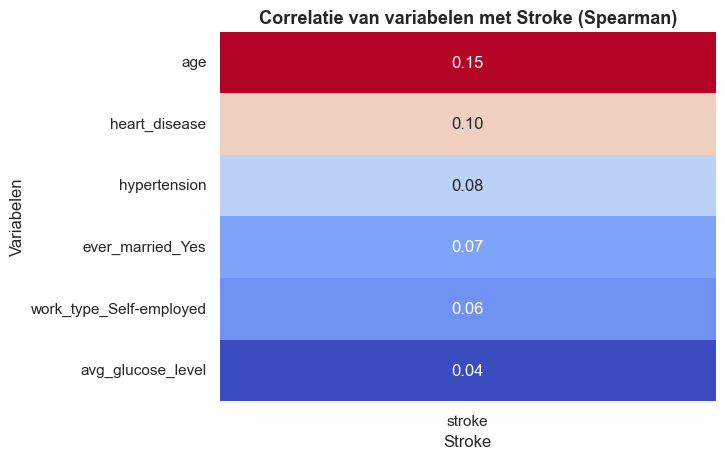

In [ ]:
# 2) Booleans → ints, daarna alleen numeriek
df_num = model.df.copy()
bool_cols = df_num.select_dtypes(include='bool').columns
df_num[bool_cols] = df_num[bool_cols].astype(int)
df_num = df_num.select_dtypes(include='number')

# 3) Spearman-correlatie (geschikt voor ordinaal/binaire variabelen)
corr = df_num.corr(method='spearman')

# 4) Alleen correlatie met 'stroke' 
corr_stroke = corr[['stroke']].drop('stroke').sort_values(by='stroke', ascending=False)

# 5) Compacte heatmap 
sns.heatmap(corr_stroke, annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title("Correlatie van variabelen met Stroke (Spearman)", fontsize=13, weight='bold')
plt.xlabel("Stroke")
plt.ylabel("Variabelen")
plt.show()

#### Opdracht 1.4
- Beschrijf wat de belangrijkste bevindingen zijn van de EDA.

**Belangrijkste bevindingen uit de EDA**

- Over het algemeen is er weinig correlatie tussen de onafhankelijke variabelen en het optreden van een beroerte (`stroke`).  
- De sterkste verbanden met `stroke` zijn te zien bij **leeftijd**, **hartziekte**, **hypertensie**, **gemiddeld glucosegehalte**, **gehuwd zijn** en **zelfstandig ondernemer (zzp’er)**.  
- De hoge correlatie tussen leeftijd en gehuwd zijn is logisch, omdat de meeste mensen trouwen op middelbare leeftijd.  
- Er is een sterke negatieve correlatie tussen `gender_Female` en `gender_Male`, omdat deze kolommen elkaars tegenhanger zijn. De categorie `gender_Other` is verwijderd, omdat die nauwelijks voorkwam.  
- We verwijderen geen variabelen met lage correlatie, omdat correlatie alleen lineaire relaties meet; niet-lineaire verbanden kunnen nog steeds belangrijk zijn voor het model.

#### Opdracht 1.5
- Sommige regels en/of kolommen zijn soms niet relevant voor machine learning. Schoon de data op zodat alleen relevante regels resteren.

Zoals hierboven al benoemt zijn er weinig correlaties, waar alleen de top 6 correlatie echt gebruikt kunnen worden en de rest is eigenlijk niet relevant omdat het een correlatie heeft die te dicht bij de nul zit waardoor het geen tot weinig invloed gaat hebben in ons model.

In [139]:
model.df = model.df.drop(['bmi','gender_Female','gender_Male','work_type_Govt_job','work_type_Never_worked','work_type_Private', 'Residence_type_Rural','smoking_status_formerly smoked', 'smoking_status_never smoked'],axis = 1)
display(model.df)


,age,hypertension,heart_disease,avg_glucose_level,ever_married_Yes,work_type_Self-employed,stroke
0,30.0,0,0,63.60,False,False,0
1,75.0,1,0,215.17,True,True,0
2,15.0,0,0,135.22,False,False,0
3,47.0,0,0,64.89,True,True,0
4,49.0,0,0,222.34,True,True,0
...,...,...,...,...,...,...,...
33545,9.0,0,0,109.80,False,False,0
33546,47.0,0,0,88.61,True,False,0
33547,3.0,0,0,89.68,False,False,0
33548,56.0,1,0,82.44,True,False,0


#### Opdracht 1.6
- Beschrijf wat wordt bedoeld met het standaardiseren van de data. Geef aan in welke gevallen dit gewenst is. Beargumenteer of het waarde toevoegt voor deze dataset en voer eventueel standaardisatie uit.

Data-standaardisatie zorgt ervoor dat alle gegevens in hetzelfde formaat en op dezelfde schaal staan.
Dit betekent dat wanneer je vergelijkingen maakt tussen twee kolommen, de waarden niet te ver van elkaar liggen.
Dit wordt vaak gedaan met behulp van een MinMaxScaler of Z-scores.
De Z-score kijkt naar de gemiddelde afwijking van het gemiddelde voor elke waarde. Deze methode is minder geschikt in ons geval, omdat veel kolommen bestaan uit 0 en 1 (of True en False). Wanneer je deze zou omzetten, kun je waarden zoals 0,8 krijgen, terwijl ze eigenlijk alleen 0 of 1 mogen zijn.
De MinMaxScaler kijkt naar de kleinste en grootste waarde in een kolom en schaalt de waarden vervolgens tussen 0 en 1. Deze methode kunnen we gebruiken om grote waarden minder extreem te maken in het model.



# Opdracht 2: Evaluatie

#### Opdracht 2.1
- Geef aan met welke “metrics”, voor deze vorm van machine learning, bepaalt kan worden hoe goed een model presteert. Toon de uitkomsten op deze metrics aan de hand van een zelf te kiezen machine learning algoritme.

Bij een binaire classificatieprobleem zoals dit gebruiken we de volgende metrics om de prestaties van een model te meten:
 - Accuracy: het percentage correcte voorspellingen.
 - Precision: van alle voorspellingen dat iemand een stroke krijgt, hoeveel waren correct?
 - Recall: van alle mensen die écht een stroke kregen, hoeveel vond het model terug?
 - F1-score: de balans tussen Precision en Recall.
 - ROC-AUC: hoe goed het model onderscheid maakt tussen stroke=0 en stroke=1 bij verschillende drempels.

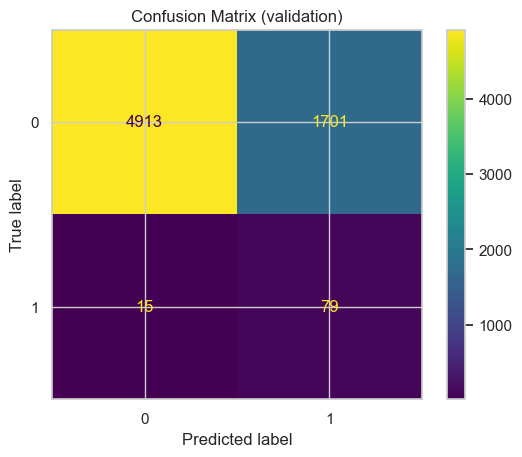

Accuracy  : 0.7442
Precision : 0.0444
Recall    : 0.8404
F1-score  : 0.0843
ROC-AUC   : 0.8817


In [140]:
# Features en target uit onze opgeschoonde df
model.split_data(target = "stroke")

# Train/valid split (80/20)
model.train_test(0.2,  42)

# Model trainen
models = LogisticRegression(max_iter=1000, class_weight="balanced")
models.fit(model.X_train, model.y_train)

# Voorspellingen
y_pred = models.predict(model.X_test)
y_proba = models.predict_proba(model.X_test)[:, 1]

# 6) Confusion matrix
cm = confusion_matrix(model.y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix (validation)")
plt.show()

# 7) Metrics
results = {
    "Accuracy": accuracy_score(model.y_test, y_pred),
    "Precision": precision_score(model.y_test, y_pred, zero_division=0),
    "Recall": recall_score(model.y_test, y_pred),
    "F1-score": f1_score(model.y_test, y_pred),
    "ROC-AUC": roc_auc_score(model.y_test, y_proba),
}
for k, v in results.items():
    print(f"{k:10s}: {v:.4f}")



Uit de confusion matrix zien we dat:

- Het model voorspelt 4913 keer correct geen stroke (True Negatives).  
- Het voorspelt 79 keer correct wel een stroke (True Positives).  
- Er zijn 15 gevallen waarin het model een stroke niet herkende (False Negatives).  
- En 1701 gevallen waarin het model **onterecht een stroke voorspelde (False Positives).

---

### Interpretatie van de scores

- **Accuracy (0.7442)** → Ongeveer 74% van alle voorspellingen is juist, maar dit komt vooral doordat het model goed is in het herkennen van mensen zonder stroke.  
- **Precision (0.0444)** → Slechts 4% van de voorspellingen "stroke" was echt correct. Er zijn dus veel *false positives*.  
- **Recall (0.8404)** → Het model herkent 84% van de echte strokes. Dat betekent dat het weinig echte strokes mist.  
- **F1-score (0.0843)** → De balans tussen precision en recall is laag, omdat de precision erg slecht is.  
- **ROC-AUC (0.8817)** → Ondanks de lage precision kan het model redelijk goed onderscheid maken tussen stroke en geen stroke, wat blijkt uit de hoge AUC-score.


#### Opdracht 2.2
- Leg uit hoe iedere metric wordt berekend. Gebruik hierbij een confusion matrix.


| Werkelijk / Voorspeld | Geen stroke (0) | Stroke (1) |
|------------------------|-----------------|-------------|
| **Geen stroke (0)** | True Negative (TN) | False Positive (FP) |
| **Stroke (1)** | False Negative (FN) | True Positive (TP) |


#### Metrics

- **Accuracy** = (TP + TN) / (TP + TN + FP + FN)  
Percentage juiste voorspellingen.

- **Precision** = TP / (TP + FP)  
Van alle voorspelde strokes, hoeveel klopten echt?

- **Recall** = TP / (TP + FN)  
Van alle echte strokes, hoeveel vond het model?

- **F1-score** = 2 × (Precision × Recall) / (Precision + Recall)  
Balans tussen Precision en Recall.

- **ROC-AUC**  
Meet hoe goed het model onderscheid maakt tussen stroke = 0 en stroke = 1 bij verschillende drempels  
(1 = perfect, 0.5 = willekeurig).

#### Opdracht 2.3
- In de Kaggle competitie zie je dat er is gekozen voor de f1-score om te beoordelen hoe goed een model presteert. Leg uit waarom f1-score voor dit vraagstuk de beste maatstaf is.

De dataset is sterk ongebalanceerd: er zijn veel meer patiënten zonder stroke (0) dan met stroke (1).
Dit geeft een probleem bij sommige metrics:
- Accuracy kan misleidend hoog zijn, omdat een model dat bijna altijd 0 voorspelt toch een hoge score haalt.
- Precision en Recall meten elk maar één kant van het verhaal: Precision kijkt of de positieve voorspellingen juist zijn. Recall kijkt of we de echte positieven vinden.
Maar in dit probleem zijn beide belangrijk:
- We willen geen patiënten met een stroke missen (hoge recall).
- We willen ook niet te veel valse alarmen (hoge precision).

De F1-score combineert Precision en Recall in één getal. Het is het gemiddelde van beide, en straft een model dat één van de twee erg laag heeft.
Daarom is de F1-score de beste maatstaf in dit vraagstuk:
- Ze geeft een eerlijk beeld van de prestaties bij een ongebalanceerde dataset.
- Ze voorkomt dat een model dat alleen maar 0 voorspelt, toch goed lijkt.
- En ze dwingt het model om een balans te vinden tussen fouten vermijden en gevallen vinden.


# Opdracht 3: Modelleren en uitleg modellen

#### K-Nearest Neighbors
- In de Kaggle competitie zie je dat er is gekozen voor de f1-score om te beoordelen hoe goed een model presteert. Leg uit waarom f1-score voor dit vraagstuk de beste maatstaf is.

Het gebruik van de F1-score als maatstaf om te bepalen welk model het best werkt, komt doordat de F1-score een combinatie is van recall en precision. Het is een harmonisch gemiddelde, wat betekent dat zowel de false positives als de false negatives worden meegenomen in de beoordeling van het model. Dit leidt tot een evenwichtige beoordeling, wat vooral voordelig is wanneer het belangrijk is om een balans te vinden tussen het vermijden van fout-positieve en fout-negatieve voorspellingen.

In [141]:
#Note ik heb heel veel weggehaald want met correlatie hebben we gezien dat heel veel het niet 
# doen waardoor je anders ruis krijgt 
cols_bool = [
    "ever_married_Yes",
    "work_type_Self-employed",
]
display(model.df)

,age,hypertension,heart_disease,avg_glucose_level,ever_married_Yes,work_type_Self-employed,stroke
0,30.0,0,0,63.60,False,False,0
1,75.0,1,0,215.17,True,True,0
2,15.0,0,0,135.22,False,False,0
3,47.0,0,0,64.89,True,True,0
4,49.0,0,0,222.34,True,True,0
...,...,...,...,...,...,...,...
33545,9.0,0,0,109.80,False,False,0
33546,47.0,0,0,88.61,True,False,0
33547,3.0,0,0,89.68,False,False,0
33548,56.0,1,0,82.44,True,False,0


In [142]:
#implementatie van 1 hot encoding
dataframe_models =  pd.get_dummies(model.df, columns=cols_bool)
model1 = Modelleren(dataframe_models)

In [143]:

#verkrijgen van y en x variablen
model1.split_data( "stroke")

#Train/valid split (80/20)
model1.train_test(0.2,  42)


#Creatie van pipline om data te standaardiseren.
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])


#Creatie van grid van hyper parameters.
param_grid_knn   = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['minkowski'],
    'knn__p': [1, 2]  # 1=Manhattan, 2=Euclidean
}

#crosvalidatie 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#gridsearch om beste hyper parameters te vinden, fitten van het model 
model1.grid(pipe_knn, param_grid_knn, cv, 'f1_weighted')
# De beste parameters 
print(model1.grids.best_params_)

{'knn__metric': 'minkowski', 'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}


Accuracy van het knn model: 0.99
Classificatie rapport:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6614
           1       0.00      0.00      0.00        94

    accuracy                           0.99      6708
   macro avg       0.49      0.50      0.50      6708
weighted avg       0.97      0.99      0.98      6708



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


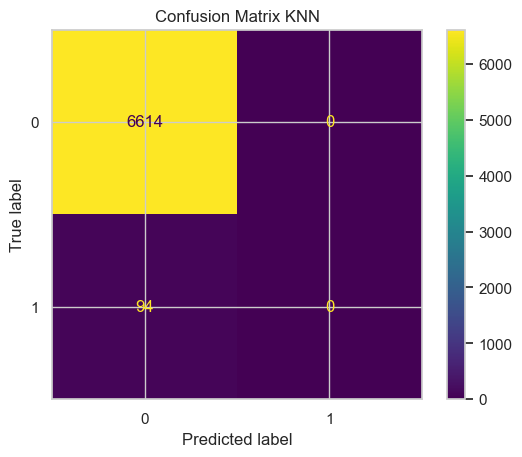

In [144]:
accuracy_knn = accuracy_score(model1.y_test, model1.y_pred)
report_knn = classification_report(model1.y_test, model1.y_pred)
conf_matrixknn = confusion_matrix(model1.y_test, model1.y_pred)

print(f"Accuracy van het knn model: {accuracy_knn:.2f}")
print("Classificatie rapport:")
print(report_knn)


cm = confusion_matrix(model1.y_test, model1.y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix KNN")
plt.show()


-	Leg uit hoe model werkt. Gebruik daarin onder andere termen “afstand”, “euclidean” en “manhattan.
-	Leg uit waarom standaardisatie voor dit model van groot belang is.
-	Bepaal bij welke hyperparameters het model de beste resultaten geeft op de gekozen metric.
-	Leg uit hoe regularisatie werkt voor dit model.




### K-Nearest Neighbors (KNN)

KNN is een simpel model dat kijkt naar de **k dichtstbijzijnde buren** van een nieuw datapunt.  
Bij classificatie kiest het model de meerderheidsklasse van die buren.  

Het model bepaalt de afstand tussen het onbekende punt en de trainingspunten.  
Daarvoor kun je verschillende manieren gebruiken:



  **Euclidisch (p = 2)** de rechte lijn tussen twee punten $$ d(x,z) = \sqrt{\sum_{i=1}^{n} (x_i - z_i)^2} $$ 
  
  **Manhattan (p = 1)** de afstand via rechte lijnen $$ d(x,z) = \sum_{i=1}^{n} \lvert x_i - z_i \rvert $$

Soms kun je ook gewogen afstanden gebruiken, waarbij de buren die dichterbij liggen meer meetellen dan die verder weg.


Standaardisatie is belangrijk bij KNN, omdat het model werkt met afstanden.  
Als één kolom (bijvoorbeeld leeftijd) veel grotere getallen heeft dan een andere (bijvoorbeeld BMI), dan beïnvloedt die kolom de afstand het meest.  
Door te standaardiseren (bijvoorbeeld met StandardScaler) komen alle kolommen op dezelfde schaal en telt elke even zwaar mee.


De belangrijkste instelling is **k** (het aantal buren):
- Kleine k (zoals 1 of 3): gevoeliger voor ruis, maar pakt details beter op.  
- Grote k (zoals 15 of 20): stabieler, maar mist soms kleine verschillen.  

Andere dingen die je kunt instellen:
- weights: of alle buren even zwaar tellen of dat de dichtste zwaarder meetelt.  
- metric: de afstandsmaat, bijvoorbeeld 'euclidean' of 'manhattan'.  

Je test meestal meerdere waarden van k en kiest die met de beste score (bijv. op F1-score of ROC-AUC).


Regularisatie bij KNN werkt eigenlijk via de keuze van **k**.  
Een kleine k kan leiden tot **overfitting** (te veel details).  
Een grote k kan leiden tot **underfitting** (te simpel model).  
Het is dus zoeken naar de juiste balans.


**Voordelen:**
- Eenvoudig: makkelijk te begrijpen en toe te passen.
- Snel te trainen: het kost weinig rekenkracht om het model te leren.
- Goed uitlegbaar: je kunt eenvoudig zien welke variabelen invloed hebben op de uitkomst.

**Nadelen:**
- Beperkt tot rechte lijnen: kan alleen lineaire relaties leren, dus geen ingewikkelde patronen.
- Niet krachtig genoeg voor complexe data: werkt minder goed bij echte, niet-lineaire situaties. 



Bij KNN-modellen is het schalen van de invoervariabelen (X) belangrijk. Meestal gebruik je of standaardisatie (gemiddelde 0, sd 1) of normalisatie/MinMax ([0,1]). Zo staan de features op vergelijkbare schaal en domineert geen enkele feature de afstandsberekening.
regelarisatie bij een KNN-model is niet mogelijk doormiddel van de standaard l1 en l2 regularisatie, om overfitting te voorkomen bij een KNN,wat de funtie is van reguralisatie, kan er gebruik worden gemaakt van K, ofwel het aantaal benodigde buren voor de clasificatie, door k te verhogen wat als waren de voorspelling "gladder" maakt omdat er een gemiddelde wordt genomen over meet data punten 

### Logistic Regression

In [145]:
# Nieuw object in oop aangemaakt voor dit model
model2 = Modelleren(dataframe_models)

#verkrijgen van y en x variablen
model2.split_data( "stroke")

# Train/valid split (80/20)
model2.train_test(0.2,  42)

#Creatie van pipline om data te standaardiseren.
pipe = make_pipeline( StandardScaler(), LogisticRegression(max_iter=5000, random_state=42, solver="saga"))

#Creatie van grid van hyper parameters.
param_grid = {
    "logisticregression__penalty": ["l1", "l2"],   # Lasso of Ridge
    "logisticregression__C": np.logspace(-2, 2, 5) 
}

#crosvalidatie 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#gridsearch om beste hyper parameters te vinden, fitten van het model
model2.grid(pipe, param_grid, cv, 'roc_auc')

# De beste parameters en grid score
print("Beste parameters:", model2.grids.best_params_)
print("Beste cross-val ROC-AUC:", model2.grids.best_score_)

Beste parameters: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l2'}
Beste cross-val ROC-AUC: 0.8526522819550315


Accuracy van het logistic regression model: 0.99
Classificatie rapport:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6614
           1       0.00      0.00      0.00        94

    accuracy                           0.99      6708
   macro avg       0.49      0.50      0.50      6708
weighted avg       0.97      0.99      0.98      6708



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


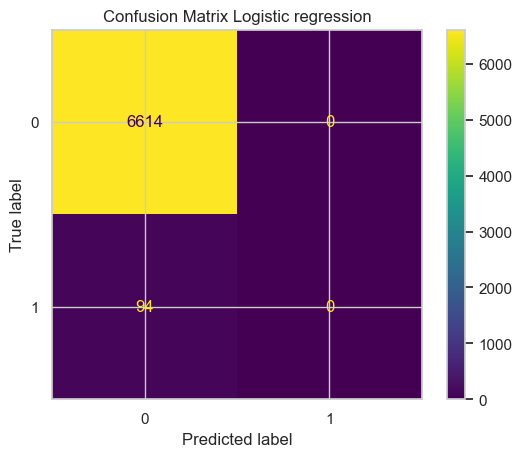

In [146]:
accuracy_lr= accuracy_score(model2.y_test, model2.y_pred)
report_lr = classification_report(model2.y_test, model2.y_pred)
conf_matrixlr = confusion_matrix(model2.y_test, model2.y_pred)

print(f"Accuracy van het logistic regression model: {accuracy_lr:.2f}")
print("Classificatie rapport:")
print(report_lr)

cm = confusion_matrix(model2.y_test, model2.y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix Logistic regression")
plt.show()

-	Leg uit hoe het model werkt.
-	Toon de wiskundig formule voor de loss-functie en licht deze toe.
-	Leg uit wat gradient descent is in deze context. Leg dit uit aan de hand van een eenvoudig rekenvoorbeeld en geef hierbij de relevant wiskundige formules.
-	Benoem de vormen van regularisatie die van toepassing zijn op dit model. Leg aan de hand van wiskundige formules uit hoe iedere vorm werkt en wat het effect is van iedere vorm.
-	Beschrijf hoe regularisatie zich verhoudt ten opzichte van overfitting?
-	Bepaal bij welke hyperparameters het model de beste resultaten geeft op de gekozen metric.


#### Uitleg

- Logistic regression is een statistieke methode voor machine learning voor het voorspellen van **binaire classificatie**. De voorspellingen komen dan in twee klassen, zoals ja/nee.

Dit is een lineaire functie:

$$
z = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p
$$

waarbij \( y \) de targetwaarde is en \( x_1, x_2, \dots \) de onafhankelijke variabelen.

En dit is de **sigmoïde functie**:

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

De sigmoïde functie levert een 'S'-vormige curve op die elk reëel getal kan omzetten in een waarde tussen 0 en 1.  
Als de curve naar plus oneindig gaat, wordt de voorspelde \( y = 1 \);  
als de curve naar min oneindig gaat, wordt \( y = 0 \).  

Als de uitkomst groter is dan 0,5, classificeren we dit als **1 (JA)**, en als deze kleiner is dan 0,5 als **0 (NEE)**.  
Bijvoorbeeld, als de uitkomst 0,75 is, betekent dit een kans van 75% dat een patiënt een beroerte krijgt.

---

### Logit-linkfunctie
De **logistische regressie** gebruikt de **logit-linkfunctie** om de lineaire combinatie van variabelen te koppelen aan de kans op een positieve uitkomst:

$$
\text{logit}(\hat{p}) = \log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = z
$$

De logit drukt dus de **log-odds** uit van de kans op \( y=1 \), en deze log-odds zijn lineair afhankelijk van de invoervariabelen.

---

### Lossfunctie: Cross-Entropy (Log Loss)

De logistische regressie minimaliseert **niet de MSE of MAE**, maar de **cross-entropy loss**, ook wel *log loss* genoemd:

$$
\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \Big[ y_i \log(\hat{p}_i) + (1 - y_i)\log(1 - \hat{p}_i) \Big]
$$

waarbij:
- \( \hat{p}_i = \sigma(z_i) \) de voorspelde kans is,
- \( y_i \) de werkelijke waarde (0 of 1) is.  

Deze functie bestraft verkeerde voorspellingen sterker naarmate ze verder van de werkelijke waarde afliggen.

---

### Gradient Descent

Gradient descent is een iteratief optimalisatie-algoritme dat de parameters van het model aanpast om de **loss** te minimaliseren.  
We initialiseren de gewichten \( w \) willekeurig en passen ze herhaaldelijk aan in de tegenovergestelde richting van de gradiënt van de lossfunctie.

De formule:

$$
\theta_{\text{nieuw}} = \theta_{\text{oud}} - \alpha \cdot \nabla L(\theta_{\text{oud}})
$$

waarbij:
- \( \theta \) = parameters (gewichten)
- \( \alpha \) = learning rate (stapgrootte)
- \( \nabla L \) = gradiënt van de loss

---

### Regularisatie

Regularisatie voorkomt **overfitting**: dat het model te veel leert van de trainingsdata, inclusief ruis.  
Het houdt de coëfficiënten klein en maakt het model algemener, waardoor het beter presteert op nieuwe data.  

Er bestaan twee veelgebruikte vormen van regularisatie:

#### Ridge (L2)
Ridge ontmoedigt grote gewichten door een straf op hun **kwadraten** te zetten:

$$
\min_{\beta} \; \| y - X\beta \|_2^2 + \lambda \| \beta \|_2^2
$$

- \( \lambda \ge 0 \): bepaalt de sterkte van de straf  
- Grote \(\lambda\): sterkere regularisatie  
- Effect: gewichten blijven klein, maar worden niet nul  

#### Lasso (L1)
Lasso ontmoedigt grote gewichten door een straf op hun **absolute waarden** te zetten:

$$
\min_{\beta} \; \| y - X\beta \|_2^2 + \lambda \| \beta \|_1
$$

- Effect: sommige gewichten worden precies **nul**  
- Voordeel: **feature selectie**, het model houdt alleen de belangrijkste variabelen over  

---

### Aannames van het model
1. Er is een lineair verband tussen de onafhankelijke variabelen en de **log-odds** van de afhankelijke variabele.  
2. De observaties zijn onafhankelijk van elkaar.  
3. Er is geen sterke multicollineariteit tussen de onafhankelijke variabelen.  

---

### Interpretatie van coëfficiënten
- Elke coëfficiënt \( \beta_i \) geeft aan hoe sterk een variabele de kans op de uitkomst beïnvloedt.  
- Als \( \beta_i > 0 \): neemt de kans op \( y=1 \) toe.  
- Als \( \beta_i < 0 \): neemt de kans op \( y=1 \) af.  
- \( e^{\beta_i} \) geeft de **odds ratio** weer — hoeveel keer de kans groter of kleiner wordt bij één eenheid stijging van die variabele.

---

### Voordelen
- Makkelijk te interpreteren en snel te trainen.  
- Werkt goed bij lineaire relaties.  
- Robuust bij binaire classificatieproblemen.  

### Nadelen
- Werkt minder goed bij niet-lineaire patronen.  
- Gevoelig voor outliers.  
- Vereist dat de variabelen onafhankelijk zijn.  

--- 





ChatGPT5.0, 2025 Prompt 1: Ridge en lasso formules https://chatgpt.com/share/68c99b12-af90-800e-a274-c8ed670e0e88
_______________________________________________________________________________________________________
### Overfitting & Regularisatie in de praktijk
- Bij overfitting leert het model te veel van de trainingsdata (ook ruis) → slechte generalisatie.  
- Regularisatie helpt dit voorkomen door coëfficiënten te verkleinen of zelfs naar 0 te brengen.  
- Dit vermindert modelcomplexiteit en helpt de belangrijkste features te selecteren. 

- Bij overfitting leert te veel van de trainingsdata, inclusief ruis → slechte generalisatie
- Hierbij kan regularisatie een belangrijke rol spelen
    - Het drukt de coeëficient kleiner en soms naar 0, dan kan je belangrijke feature selecteren
    - Het vermindert modelcomplexiteit
_____________________________________________________________________________________________________

Beste parameters: {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l1'}
Beste cross-val ROC-AUC: 0.851335719802982

- penalty='l1' --> Lasso, hij selecteert belangrijkste features
- C=0.01 --> sterke regularisatie  
- metric ROC-AUC wordt vaak gebruikt bij binaire classificatieproblemen. Het meet hoe goed het model onderscheid kan maken tussen de positieve klasse (1) en de negatieve klasse (0).

#### SVM

In [147]:

model3 = Modelleren(dataframe_models)
model3.split_data("stroke")
model3.train_test(0.2, 42)

# --- Pipeline ---
pipe = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", probability=False, cache_size=2000, random_state=42)
)

# --- Parameter search space ---
param_dist = {
    "svc__C": np.logspace(-3, 3, 100),          #
    "svc__gamma": np.logspace(-5, 2, 100),      
    "svc__class_weight": [None, "balanced"],
}

# --- Cross-validation setup ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Halving Random Search ---
search = HalvingRandomSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    factor=3,                   
    resource="n_samples",        
    max_resources="auto",         
    scoring="f1",
    n_jobs=-1,
    cv=cv,
    random_state=42,
    verbose=1
)

# --- Run search ---
search.fit(model3.X_train, model3.y_train)

# --- Results ---
print("Beste parameters:", search.best_params_)
print("Beste cross-val ROC-AUC:", search.best_score_)


n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 20
max_resources_: 26829
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1341
n_resources: 20
Fitting 5 folds for each of 1341 candidates, totalling 6705 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packa

----------
iter: 1
n_candidates: 447
n_resources: 60
Fitting 5 folds for each of 447 candidates, totalling 2235 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packa

----------
iter: 2
n_candidates: 149
n_resources: 180
Fitting 5 folds for each of 149 candidates, totalling 745 fits


...

----------
iter: 5
n_candidates: 6
n_resources: 4860
Fitting 5 folds for each of 6 candidates, totalling 30 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1102: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.07083423 0.08248731 0.0813306 ]
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1102: UserWarning: One or more of the train scores are non-finite: [       nan        nan        nan ... 0.08421227 0.0937501  0.09241692]
  warnings.warn(


----------
iter: 6
n_candidates: 2
n_resources: 14580
Fitting 5 folds for each of 2 candidates, totalling 10 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1102: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.0813306  0.08403389 0.08289925]
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1102: UserWarning: One or more of the train scores are non-finite: [       nan        nan        nan ... 0.09241692 0.09108845 0.0901176 ]
  warnings.warn(


Beste parameters: {'svc__gamma': 0.0009545484566618337, 'svc__class_weight': 'balanced', 'svc__C': 13.219411484660288}
Beste cross-val ROC-AUC: 0.08403389432461841


Accuracy van het svm model: 0.73
Classificatie rapport:
              precision    recall  f1-score   support

           0       1.00      0.73      0.84      6614
           1       0.04      0.85      0.08        94

    accuracy                           0.73      6708
   macro avg       0.52      0.79      0.46      6708
weighted avg       0.98      0.73      0.83      6708



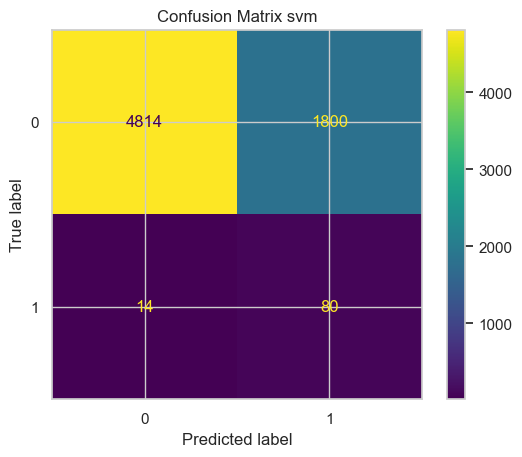

In [148]:
y_pred = search.predict(model3.X_test)


accuracy_svm = accuracy_score(model3.y_test,y_pred)
report_svm = classification_report(model3.y_test,y_pred)
conf_matrixsvm = confusion_matrix(model3.y_test, y_pred)

print(f"Accuracy van het svm model: {accuracy_svm:.2f}")
print("Classificatie rapport:")
print(report_svm)

cm = confusion_matrix(model3.y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix svm")
plt.show()

-	Beschrijf de werking van dit model. Toon hierbij de relevante wiskundige formules en leg ze uit aan de hand van een rekenvoorbeeld. Gebruik hierbij een klein deel van de dataset. Leg ook uit wat een kernel is en wat de kernel trick is.
-	Toon de wiskundig formule voor de loss functie en ligt deze toe.
-	Benoem de vormen van regularisatie die van toepassing zijn op dit model. Leg aan de hand van wiskundige formules uit hoe iedere vorm werkt en wat het effect is van iedere vorm.
-	Bepaal bij welke hyperparameters het model de beste resultaten geeft op de gekozen metric.
-----


Een SVM-model is, net als veel andere modellen, een classificatiemodel dat op basis van een trainingsdataset voorspellingen kan doen over de klasse waartoe nieuwe datapunten behoren.  

Binnen de dataset zijn er vaak meerdere *features* die samen de classificatie bepalen. Je kunt deze punten visualiseren door de features uit te zetten als coördinaten. Het kan dan gebeuren dat de data zich verdeelt in twee groepen. Hier komt SVM in beeld: het model zoekt een lijn (of in hogere dimensies: een hypervlak) die de twee groepen zo goed mogelijk scheidt. Voor dit voorbeeld beperken we ons tot de lineaire SVM.  



 
Om te beginnen is het belangrijk om te begrijpen hoe een lineaire functie werkt.  

De standaardvorm is  

$$
y = ax + b
$$  
waarbij

\(a\) = de helling (slope) van de lijn  
\(b\) = het snijpunt met de y-as  
\(x\) = de feature(s)  




Voor SVM wordt de vergelijking vaak herschreven naar de algemene/vector vorm
voor algemeen 2d gebruik
$$
Ax + By + C = 0
$$  
als vecotor voor hogere niveaus
$$
w⋅x+b=0
$$

Note: bij een dataframe zou de vector formule als volgt zijn
$$
f(X)=w1​x1​+w2​x2​+⋯+wn​xn​+b
$$ 

Met deze vorm kun je eenvoudig bepalen aan welke kant van de lijn een nieuw punt \((x, y)\) ligt:  

Als de uitkomst \(> 0\), ligt het punt aan de ene kant.  
Als de uitkomst \(< 0\), ligt het punt aan de andere kant.  
Als de uitkomst \(= 0\), ligt het punt precies op de lijn.  

Voorbeeld

Stel we hebben de lijn  

$$
y = 0.5x + 1
$$  

Dit kan worden herschreven naar de algemene vorm:  

$$
-2x + 4y - 4 = 0
$$  

Als we nu het punt \((x=5, y=4)\) invullen:  


$$
-2 \cdot 5 + 4 \cdot 4 - 4 = 2
$$  

De uitkomst is \(2 > 0\), dus het punt ligt boven de lijn en behoort daarmee tot één van de twee klassen.  




Een belangrijk onderdeel van SVM is dat het niet alleen de scheidslijn bepaalt, maar ook marges aan weerszijden van die lijn. Dat zijn lijnen die parallel lopen aan de scheidslijn.  

Bijvoorbeeld:  

$$
-2x + 4y - 4 = 1
$$  

$$
-2x + 4y - 4 = 0
$$  

$$
-2x + 4y - 4 = -1
$$  

De middelste lijn is de scheidslijn, en de lijnen erboven en eronder zijn de marges.  

Door de coëfficiënten te schalen (vermenigvuldigen met een factor) kan de afstand tussen de marges worden aangepast 

vermenigvuldigen met een getal kleiner dan 1 = grotere marge  
vermenigvuldigen met een getal groter dan 1 = kleinere marge  

Het doel van SVM is om de lijn te vinden waarbij de marge zo groot mogelijk is, terwijl de twee groepen correct gescheiden blijven.  


Verders is het belangrijk om te kunnen bepalen hoe ver een punt van de lijn aflight,dit kan berekent worden door de formule

$$
d = \frac{|Ax_0 + By_0 + C|}{\sqrt{A^2 + B^2}}
$$



Wanneer er gebruik wordt gemaakt van SVM op een dataset gebeurt het volgende:
de optimale hyperplane wordt bepaald. Dit is de lijn (in 2D) of het vlak (in hogere dimensies) dat de klassen zo goed mogelijk van elkaar scheidt met de grootste marge.

Vervolgens worden de support vectors geïdentificeerd. Dit zijn de datapunten die het dichtst bij de hyperplane liggen. Er liggen minimaal één of meerdere punten aan beide zijden van de hyperplane die deze rol vervullen.

De afstand van deze support vectors tot de hyperplane bepaalt de marge. Het doel van SVM is om deze marge zo groot mogelijk te maken, zodat de scheiding tussen de klassen zo robuust mogelijk is.

Wanneer nieuwe punten worden toegevoegd, kan met behulp van de vergelijking van de hyperplane worden bepaald aan welke zijde van de scheidslijn het punt valt en dus tot welke klasse het behoort.

### Kernel trick

Bij niet-lineaire data gebruiken we de **kernel trick**.  
Het idee: we doen alsof we de data naar een hogere dimensie mappen met een functie $\phi(x)$,  
maar **we berekenen die mapping nooit expliciet**.  
In de duale SVM-formulering komen alleen **inproducts (dot-products)** tussen voorbeelden voor.  
We vervangen die inproducts door een **kernel** $K(x, z)$ die hetzelfde resultaat geeft als het inproduct in de hogere ruimte:

$$
K(x, z) = \phi(x) \cdot \phi(z)
$$

Zo kunnen we in een (impliciet) hogerdimensionale ruimte een **lineaire hyperplane** vinden,  
zonder de complexe functie $\phi(x)$ echt uit te rekenen.

**Veelgebruikte kernels:**

- **Lineair:**  
  $$
  K(x, z) = x \cdot z
  $$
- **Polynomiaal:**  
  $$
  K(x, z) = (x \cdot z + c)^d
  $$
- **RBF (Gaussian):**  
  $$
  K(x, z) = e^{-\gamma \|x - z\|^2}
  $$


Met $K$ berekenen we direct de inproducts in de hoge ruimte, waardoor data die in 2D niet lineair scheidbaar is,  
**wel lineair scheidbaar** kan worden in die hogere (impliciete) ruimte.






ChatGPT5.0, 2025 Prompt :evalueer mijn uitleg. https://chatgpt.com/share/68d9222f-ceac-800d-b0cf-d94f8f2aea8c

#### Loss function SVM
De loss function is een manier om aan te tonen hoe goed of hoe slecht een model werkt, door te kijken naar hoeveel een voorspelling afwijkt van de echte waarden. Bij SVM kan er gebruikgemaakt worden van een hinge loss om te bepalen hoe goed een model presteert. Het is wel belangrijk om in gedachten te houden dat hinge loss alleen nodig is bij een soft margin SVM-model.  

De loss function van hinge SVM ziet er als volgt uit:

$$
L(y, f(x)) = \max\!\bigl(0,\, 1 - y\, f(x)\bigr)
$$

De formule neemt een marge of afstand tot de classificatiegrenzen (scheidingslijnen) mee in de berekening van de loss. Het unieke hieraan is dat zelfs als een nieuw datapunt juist wordt voorspeld, er nog steeds een penalty kan zijn als de marge ten opzichte van de scheidingslijnen niet groot genoeg is.  

Voorbeeld

$$
y_i \in \{-1, +1\}
$$

$$
f(x) = w^T x + b
$$

Hierboven is het domein en de decision function te zien.  

Bij misclassificatie waarbij 1 is voorspeld maar de true waarde -1 is:

$$
L = 1 - (1)(-1) = 1 - (-1) = 1 + 1 = 2
$$

In dit geval is de loss hoog, namelijk 2.  

Maar bij een geval van juiste classificatie:

$$
L = 1 - (1)(1) = 1 - 1 = 0
$$

is de uitkomst 0.  

Dus bij hinge loss kunnen de waarden tussen 0 en oneindig liggen, waarbij 0 een lage loss is en dus wijst op een efficiënt model, en in dit geval 2 een hoge loss en een inefficiënt model betekent.


tenslotte is het belangrijk dat een model geregulariseerd wordt om de performance te optimaliseren. Bij SVM gebeurt dit door een afweging te maken tussen het maximaliseren van de marge en het minimaliseren van fouten. Deze afweging wordt geregeld door de hyperparameter 𝐶  
zoals te zien is in de formule
$$
min_{w,b,\xi} \;\; \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \xi_i
$$

deze waarde geeft aan hoe zwaar fouten worden bestraft in het model, hierbij wanner c groter gemaakt worden de marges kleiner en visa versa wanneer c kleiner wordt gemaakt de marges groter. 
bij de hyperparameter c kan dus overfitting worden geprefreerd door c te verhogen 

SVM voor en nadelen 

Voordelen:

Werkt goed bij kleine tot middelgrote datasets met duidelijke marges.

Robuust tegen overfitting door de maximale marge.

Flexibel dankzij verschillende kernels (werkt ook bij niet-lineaire data).

Nadelen:

Rekentijd loopt snel op bij grote datasets.

Moeilijk te interpreteren bij niet-lineaire kernels.

Gevoelig voor keuze van kernel en hyperparameters.

#### Decision Tree

In [149]:
#code
# Nieuw object in oop aangemaakt voor dit model
model4 = Modelleren(dataframe_models)

#verkrijgen van y en x variablen
model4.split_data( "stroke")

# Train/valid split (80/20)
model4.train_test(0.2,  42)

#Creatie van pipline om data te standaardiseren.
pipe = make_pipeline( StandardScaler(), DecisionTreeClassifier(criterion="gini",class_weight="balanced",random_state=42))

# Hyperparameters die we willen proberen
param_grid = {
    "decisiontreeclassifier__max_depth": [4, 6, 8, 10],  # maximale diepte van de boom
    "decisiontreeclassifier__min_samples_leaf": [1, 5, 10],  # minimaal aantal samples in een blad
    "decisiontreeclassifier__min_samples_split": [2, 5, 10]  # minimaal aantal samples om te splitsen
}

# We willen F1-score voor de positieve klasse (stroke=1) maximaliseren
scorer = make_scorer(f1_score, pos_label=1)

#crosvalidatie 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#gridsearch om beste hyper parameters te vinden, fitten van het model
model4.grid(pipe, param_grid, cv, scorer)

# De beste parameters en grid score
print("Beste parameters:", model4.grids.best_params_)
print("Beste cross-val F1 (klasse 1)", model4.grids.best_score_)


Beste parameters: {'decisiontreeclassifier__max_depth': 8, 'decisiontreeclassifier__min_samples_leaf': 10, 'decisiontreeclassifier__min_samples_split': 2}
Beste cross-val F1 (klasse 1) 0.0903969129760602


In [150]:
#Ik heb feature_importances extra gedaan omdat feature importances laat zien welke variabelen het belangrijkst zijn voor de voorspelling. 
# Zo begrijp je beter waarom het model een beslissing maakt en kun je het makkelijker uitleggen.

# Beste model uit gridsearch pakken
best_model = model4.grids.best_estimator_

# Feature importances ophalen
importances = best_model.named_steps['decisiontreeclassifier'].feature_importances_

# Omzetten naar een overzichtelijke tabel (top 15 belangrijkst)
fi = pd.Series(importances, index=model4.X.columns).sort_values(ascending=False).head(15)

print("Belangrijkste features volgens het Decision Tree model:")
print(fi)

Belangrijkste features volgens het Decision Tree model:
age                              0.749899
avg_glucose_level                0.183833
hypertension                     0.022609
heart_disease                    0.017521
work_type_Self-employed_False    0.016777
work_type_Self-employed_True     0.004302
ever_married_Yes_True            0.003722
ever_married_Yes_False           0.001338
dtype: float64


Accuracy van het decision tree model: 0.81
Classificatie rapport:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      6614
           1       0.05      0.69      0.09        94

    accuracy                           0.81      6708
   macro avg       0.52      0.75      0.49      6708
weighted avg       0.98      0.81      0.88      6708



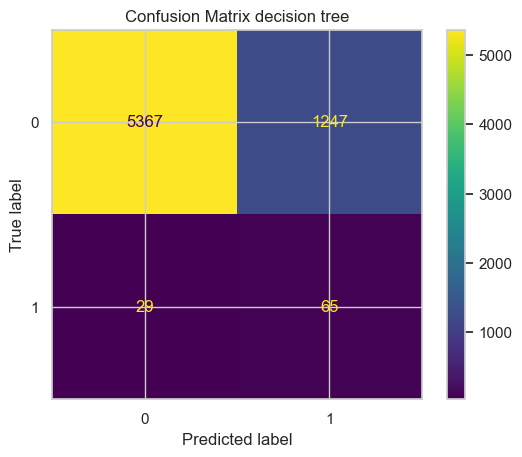

In [151]:
accuracy_dt = accuracy_score(model4.y_test, model4.y_pred)
report_dt = classification_report(model4.y_test, model4.y_pred)
conf_matrixdt = confusion_matrix(model4.y_test, model4.y_pred)

print(f"Accuracy van het decision tree model: {accuracy_dt:.2f}")
print("Classificatie rapport:")
print(report_dt)

cm = confusion_matrix(model4.y_test, model4.y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix decision tree")
plt.show()

-	Beschrijf de werking van dit model.

Antwoord: Een Decision Tree Classifier werkt als een soort stroomdiagram waarin bij elke stap een vraag wordt gesteld, bijvoorbeeld of de leeftijd groter is dan een bepaalde waarde. Afhankelijk van het antwoord wordt de rij naar links of rechts gestuurd en uiteindelijk komt de rij in een blad terecht waar de voorspelling wordt gedaan, in dit geval stroke of geen stroke. Het model leert deze vragen automatisch op basis van de data en probeert zo goed mogelijk onderscheid te maken tussen de twee klassen.

Een groot voordeel van Decision Trees is dat ze makkelijk te interpreteren zijn.  
Je kunt precies zien welke vragen het model stelt, in welke volgorde en waarom een bepaalde beslissing wordt genomen.  
Elke tak laat zien welke voorwaarden leiden tot een bepaalde uitkomst, wat het model transparant en uitlegbaar maakt.

**Voordelen:**
- Eenvoudig te begrijpen en te gebruiken.  
- Makkelijk te verklaren modellen (visueel inzichtelijk).  
- Kan complexe, niet-lineaire relaties modelleren.  

**Nadelen:**
- Veel hyperparameters, kost tijd om goed af te stemmen.  
- Gevoelig voor overfitting (zeker bij diepe bomen).

-	Beschrijf de criteria op basis waarvan de splitsingen in de beslisboom kunnen worden gemaakt.

Antwoord: De beslisboom bepaalt welke vraag hij stelt door een criterium te gebruiken dat meet hoe zuiver de splitsing is. In dit model is gekozen voor de Gini-index. Deze maat kijkt hoe gemengd de klassen in een groep zijn en kiest de splitsing die de klassen het best scheidt. Hoe lager de Gini-index, hoe beter de scheiding.

Een ander criterium dat Decision Trees kunnen gebruiken is entropie.  
Entropie meet de hoeveelheid "chaos" in een groep: Hoe lager de entropie, hoe zuiverder de groep.  
De boom kiest telkens de splitsing die de grootste afname in entropie oplevert.

-	Bepaal bij welke hyperparameters het model de beste resultaten geeft op de gekozen metric.

Antwoord: Uit het testen bleek dat het model het beste werkte met een maximale diepte van tien, minstens één voorbeeld in een blad en minstens twee voorbeelden om te splitsen. Met deze instellingen herkende de boom genoeg patronen, maar werd hij niet te groot.

-	Leg uit wat ‘pruning’ is en beschrijf welke vormen hiervan zijn toegepast. Leg de relatie tussen ‘pruning’ en ‘underfitting / overfitting’ uit.

Antwoord: Pruning betekent dat je de boom kleiner maakt zodat hij niet te ingewikkeld wordt. Dit kan vooraf tijdens het bouwen of achteraf door takken weg te halen. In dit model is vooraf begrensd, bijvoorbeeld door de maximale diepte in te stellen. Zonder pruning wordt de boom te groot en leert hij te veel details (overfitting). Met te veel pruning wordt de boom te simpel en mist hij verbanden (underfitting). De gekozen instellingen zorgen voor een goede balans.


#### Ensembles (Random Forest, Gradient Boosted Decistion Trees en XGboost)

#### - Random forest

In [152]:

# Nieuw object in oop aangemaakt voor dit model
model5 = Modelleren(dataframe_models)

#verkrijgen van y en x variablen
model5.split_data( "stroke")

# Train/valid split (80/20)
model5.train_test(0.2,  42)

#model maken
rf = RandomForestClassifier(
    n_estimators=500, 
    class_weight='balanced',         
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

#hyperparameters voorstellen
param_grid1 = {
    'max_depth': [4, 6, 8, 10],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



In [153]:
#gridsearch
model5.grid(rf, param=param_grid1, cv_grid=cv, scoring='roc_auc', jobs=-1)

Best params: {'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV AUC: 0.8454521422152196
Accuracy van het random forest model: 0.70
Classificatie rapport:
              precision    recall  f1-score   support

           0       1.00      0.70      0.82      6614
           1       0.04      0.87      0.08        94

    accuracy                           0.70      6708
   macro avg       0.52      0.79      0.45      6708
weighted avg       0.98      0.70      0.81      6708



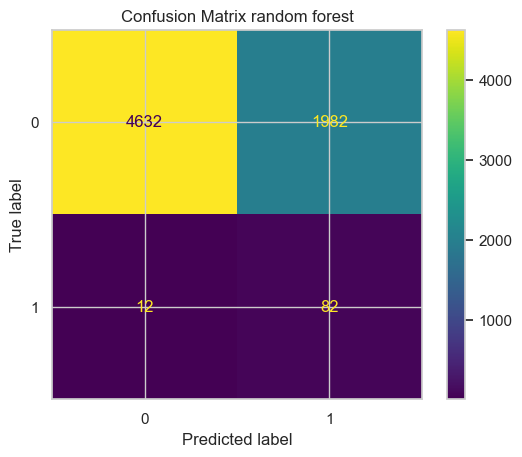

In [154]:
print("Best params:", model5.grids.best_params_)
print("Best CV AUC:", model5.grids.best_score_)
accuracy_rf = accuracy_score(model5.y_test, model5.y_pred)
report_rf = classification_report(model5.y_test, model5.y_pred)
conf_matrixrf = confusion_matrix(model5.y_test, model5.y_pred)

print(f"Accuracy van het random forest model: {accuracy_rf:.2f}")
print("Classificatie rapport:")
print(report_rf)

cm = confusion_matrix(model5.y_test, model5.y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix random forest")
plt.show()

#### - Gradient Boosted Decistion Trees

In [155]:

# Nieuw object in oop aangemaakt voor dit model
model52 = Modelleren(dataframe_models)

#verkrijgen van y en x variablen
model52.split_data( "stroke")

# Train/valid split (80/20)
model52.train_test(0.2,  42)

#model maken
gbt = GradientBoostingClassifier(
    n_estimators=500, 
    loss="log_loss", #minimaliseren (logistische loss) → levert nette kansen.
    random_state=42, 
    validation_fraction=0.1, # early stopping --> Splitst intern een validatieset af
    n_iter_no_change=30,    #Stopt als validatie-score niet verbetert binnen
)

#hyperparameters voorstellen
param_grid2 = {
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0], #fractie van de trainingsdata per boosting-stap --> reduceert overfit
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [1, 5, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [156]:
#gridsearch
model52.grid(gbt, param=param_grid2, cv_grid=cv, scoring='roc_auc', jobs=-1)

Best params: {'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 5, 'subsample': 1.0}
Best CV AUC: 0.8520890670420315
Accuracy van het Gradient Boosted Decistion Trees model: 0.99
Classificatie rapport:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      6614
           1       0.00      0.00      0.00        94

    accuracy                           0.99      6708
   macro avg       0.49      0.50      0.50      6708
weighted avg       0.97      0.99      0.98      6708



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


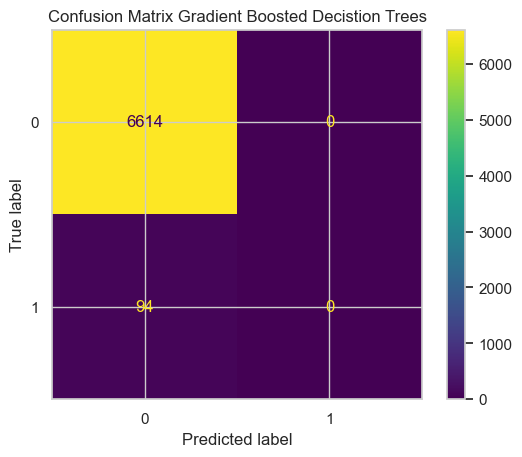

In [157]:
print("Best params:", model52.grids.best_params_)
print("Best CV AUC:", model52.grids.best_score_)
accuracy_gbt = accuracy_score(model52.y_test, model52.y_pred)
report_gbt = classification_report(model52.y_test, model52.y_pred)
conf_matrixgbt = confusion_matrix(model52.y_test, model52.y_pred)

print(f"Accuracy van het Gradient Boosted Decistion Trees model: {accuracy_gbt:.2f}")
print("Classificatie rapport:")
print(report_gbt)

cm = confusion_matrix(model52.y_test, model52.y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix Gradient Boosted Decistion Trees")
plt.show()

#### - XGboost

In [158]:
# Nieuw object in oop aangemaakt voor dit model
modelx = Modelleren(dataframe_models)

#verkrijgen van y en x variablen
modelx.split_data( "stroke")

# Train/valid split (80/20)
modelx.train_test(0.2,  42)

#berekent de klasse-ongebalanceerdheid
pos = (modelx.y_train == 1).sum()
neg = (modelx.y_train == 0).sum()
neg_pos = neg / max(1, pos)

# Instant het model
xgb = XGBClassifier(
    tree_method="hist", 
    n_estimators=600,    
    scale_pos_weight=neg_pos,
    eval_metric="auc",
    n_jobs=1,                 
    random_state=42
)

param_gridx = {
    "max_depth": [2, 4, 6, 8],
    "min_child_weight": [1, 2, 5], #minimum “gewicht” (ongeveer aantal/importance) dat nodig is om een blad te maken.
    "reg_lambda": [0.5, 1.0, 2.0], #L2
    "reg_alpha": [0.0, 0.1, 0.5], #L1
    "learning_rate": [0.03, 0.05, 0.1]
}





In [159]:
#gridsearch
modelx.grid(xgb, param=param_gridx, cv_grid=cv, scoring='roc_auc', jobs=-1)

KeyboardInterrupt: 

Best params: {'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 5, 'reg_alpha': 0.5, 'reg_lambda': 2.0}
Best CV AUC: 0.84746540151041
Accuracy van het XGboost model: 0.75
Classificatie rapport:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86      6614
           1       0.05      0.86      0.09        94

    accuracy                           0.75      6708
   macro avg       0.52      0.81      0.47      6708
weighted avg       0.98      0.75      0.84      6708



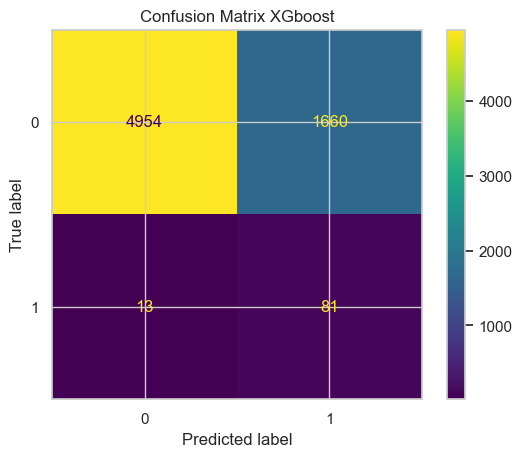

In [ ]:
print("Best params:", modelx.grids.best_params_)
print("Best CV AUC:", modelx.grids.best_score_)
accuracy_xg = accuracy_score(modelx.y_test, modelx.y_pred)
report_xg = classification_report(modelx.y_test, modelx.y_pred)
conf_matrixxg = confusion_matrix(modelx.y_test, modelx.y_pred)

print(f"Accuracy van het XGboost model: {accuracy_xg:.2f}")
print("Classificatie rapport:")
print(report_xg)

cm = confusion_matrix(modelx.y_test, modelx.y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix XGboost")
plt.show()

-	Beschrijf de werking van de 3 genoemde ensembles. Gebruik daarbij o.a. de termen “bagging (bootstrap aggregation)” en “boosting “. Leg daarbij uit welke ensembles relatief veel trainingstijd nodig hebben en welke weinig tijd. Gebruik daarbij o.a. de termen “sequential” en “parallel”.

    - Randomforest:
    Random Forest wordt gedefinieerd als een ensemble-leermethode waarbij tijdens de training een groot aantal beslissingsbomen wordt geconstrueerd, waarbij de uitvoer óf de gemiddelde voorspelling voor regressie óf de modus van de klassen voor classificatie is. Veelgebruikte ensemblemethoden zijn bootstrap-aggregation (ook wel 'bagging' genoemd) en boosting. Bij de bagging-methode wordt een willekeurige subset van features (max_features) uit een trainingsset geselecteerd met teruglegging, wat betekent dat de individuele datapunten meerdere keren gekozen kunnen worden. Nadat er meerdere datasteekproeven zijn gegenereerd, worden alle bomen  onafhankelijk en dus parallel getraind.. training snel–middel (goed paralleliseerbaar). Predictie is trager dan één model, want je evalueert veel bomen.

    - Gradient Boosted Decistion Trees:
    Gradient-Boosted Decision Trees (GBDT) zijn een krachtige machine learning-techniek die een sterk voorspellend model bouwt door meerdere eenvoudige beslissingsbomen, of "zwakke leerlingen", sequentieel te combineren. Elke nieuwe boom corrigeert de residuen/fouten van het huidige ensemble en minimaliseert zo de gekozen verliesfunctie via functionele gradiëntstappen. Met Klassieke GradientBoostingClassifier is het process langzaam. klassieke GradientBoostingClassifier is relatief traag; de histogram-variant HistGradientBoostingClassifier is veel sneller, maar blijft sequential over iteraties.

    - XGboost:
    XGBoost, wat staat voor "eXtreme Gradient Boosting", is een geavanceerde implementatie van het gradient boosting. Gradient boosting is een machine learning-techniek waarbij het hoofddoel is om vele eenvoudige modellen, ook wel "zwakke leerlingen" genoemd, te combineren om een ​​ensemblemodel te creëren dat beter is in voorspellen. Hetconcept van XGBoost, net als bij andere boostingmethoden, is het sequentieel toevoegen van nieuwe modellen aan het ensemble. In tegenstelling tot baggingmethoden zoals Random Forest, waarbij bomen parallel groeien, trainen boostingmethoden modellen één voor één, waarbij elke nieuwe boom helpt bij het corrigeren van fouten die door de eerder getrainde boom zijn gemaakt. Of in andere woorden he model wordt “sequential” manier getraind. is parallelliseerbaar, wat betekent dat het meerdere CPU-cores kan gebruiken om modellen sneller te trainen.


**Bagging** traint veel modellen parallel, dus allemaal tegelijk. Elk model leert onafhankelijk van de anderen op willekeurige subsets van de data. Het doel van bagging is om de variantie te verlagen, waardoor het model stabieler wordt en minder gevoelig is voor ruis. Omdat alle modellen tegelijk worden getraind, is bagging meestal sneller dan boosting.

**Boosting** werkt juist sequentieel. Dat betekent dat elk nieuw model wordt getraind om de fouten van het vorige te corrigeren. Het doel van boosting is om de bias te verlagen, waardoor het model nauwkeuriger wordt.  
Boosting levert vaak een krachtiger model op, maar het duurt langer om te trainen omdat de modellen na elkaar worden gebouwd.

############In deze dataset werkte **XGBoost** het beste met de hoogste ROC-AUC-score. 
Dat komt doordat XGBoost fouten van eerdere bomen corrigeert en regularisatie toepast om overfitting te voorkomen.  
Random Forest presteerde stabiel, maar iets minder nauwkeurig.  
Gradient Boosted Trees waren nauwkeurig, maar trager om te trainen.

**Voordelen:**
- Hogere nauwkeurigheid dan één enkel model.  
- Minder gevoelig voor ruis of variatie in data.  
- Combinatie van zwakke modellen leidt tot een sterk model.  

**Nadelen:**
- Meer rekentijd en geheugen nodig.  
- Moeilijker te interpreteren.  
- Boosting-modellen zijn trager te trainen dan bagging-modellen.

-	Bepaal bij welke hyperparameters ieder ensemble de beste resultaten geeft op de gekozen metric.
    - Randomforest:
    Best params: {'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}

    - Gradient Boosted Decistion Trees:
    Best params: {'learning_rate': 0.03, 'max_depth': 2, 'min_samples_leaf': 5, 'subsample': 1.0}

    - XGboost:
    Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'subsample': 1.0} ##############


#### Zelf samengesteld ensemble

Accuracy van het ensemble model: 0.92
Classificatie rapport:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      6614
           1       0.08      0.46      0.14        94

    accuracy                           0.92      6708
   macro avg       0.54      0.69      0.55      6708
weighted avg       0.98      0.92      0.95      6708



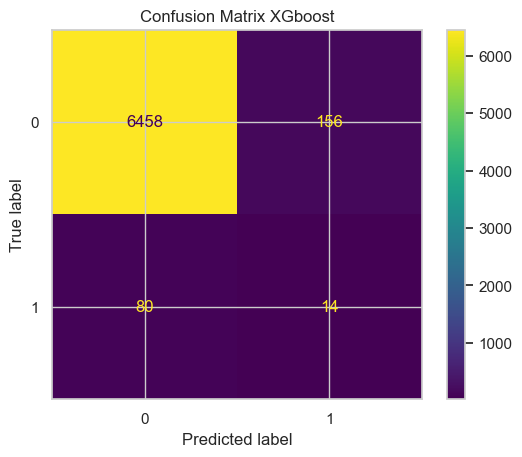

In [ ]:

# Nieuw object in oop aangemaakt voor dit model
model6 = Modelleren(dataframe_models)  # Gebruik Model6 nu

# Verkrijgen van y en x variabelen
model6.split_data("stroke")

# Train/valid split (80/20)
model6.train_test(0.2, 42)

# Ensemble model met Grid Search voor Hyperparameter Tuning
# Definieer de pijplijnen voor elk model

# Decision Tree
dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

# Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('lr', LogisticRegression(random_state=42, max_iter=200, class_weight='balanced'))
])

# KNN
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsClassifier())
])

# Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# XGBoosting
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
])

# Definieer de parameter grids voor elke pijplijn
dt_param_grid = {
    'dt__max_depth': [3, 5, 7],
    'dt__min_samples_split': [2, 5, 10]
}

lr_param_grid = {
    'lr__C': [0.1, 1, 10],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear']  # voor l1
}

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance']
}

rf_param_grid = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20],
    'rf__min_samples_split': [2, 5]
}

xgb_param_grid = {
    'xgb__n_estimators': [50, 100],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__scale_pos_weight': [1, 10, 50]
}

# Voer Grid Search uit voor elk model
model6.grid(dt_pipeline, dt_param_grid, cv_grid=3, scoring='f1', jobs=-1)
dt_best_model = model6.grids.best_estimator_

model6.grid(lr_pipeline, lr_param_grid, cv_grid=3, scoring='f1', jobs=-1)
lr_best_model = model6.grids.best_estimator_

model6.grid(knn_pipeline, knn_param_grid, cv_grid=3, scoring='f1', jobs=-1)
knn_best_model = model6.grids.best_estimator_

model6.grid(rf_pipeline, rf_param_grid, cv_grid=3, scoring='f1', jobs=-1)
rf_best_model = model6.grids.best_estimator_

model6.grid(xgb_pipeline, xgb_param_grid, cv_grid=3, scoring='f1', jobs=-1)
xgb_best_model = model6.grids.best_estimator_

# Maak het ensemble model met de best getunede modellen
# Maak de Voting Classifier aan met de best getunede modellen
ensemble = VotingClassifier(
    estimators=[
        ('decision_tree', dt_best_model),
        ('logistic_regression', lr_best_model),
        ('knn', knn_best_model),
        ('random_forest', rf_best_model),
        ('xgboost', xgb_best_model)
    ],
    voting='soft'  # 'hard' of 'soft'
)

# Train het ensemble model
ensemble.fit(model6.X_train, model6.y_train)

# Voorspellingen
y_pred_ensemble = ensemble.predict(model6.X_test)

# Scorings
accuracy_ensemble = accuracy_score(model6.y_test, y_pred_ensemble)
report_ensemble = classification_report(model6.y_test, y_pred_ensemble)
conf_matrix = confusion_matrix(model6.y_test, y_pred_ensemble)

print(f"Accuracy van het ensemble model: {accuracy_ensemble:.2f}")
print("Classificatie rapport:")
print(report_ensemble)


cm = confusion_matrix(model6.y_test, model6.y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix XGboost")
plt.show()

In [ ]:
# Overzicht van beste hyperparameters en scores per model

# Lijst van modellen en namen
beste_modellen = {
    'Decision Tree': dt_best_model,
    'Logistic Regression': lr_best_model,
    'KNN': knn_best_model,
    'Random Forest': rf_best_model,
    'XGBoost': xgb_best_model
}

# Print beste parameters en F1-score per model
from sklearn.metrics import f1_score
from pprint import pprint

print("Overzicht van beste hyperparameters en F1-scores per model:\n")
for naam, model in beste_modellen.items():
    # Voorspelling op testset
    y_pred = model.predict(model6.X_test)
    f1 = f1_score(model6.y_test, y_pred)
    
    print(f"   {naam}")
    pprint(f"   Beste hyperparameters: {model.get_params()}")
    print(f"   F1-score op testset: {f1:.4f}\n")


Overzicht van beste hyperparameters en F1-scores per model:

   Decision Tree
("   Beste hyperparameters: {'memory': None, 'steps': [('scaler', "
 "StandardScaler()), ('dt', DecisionTreeClassifier(class_weight='balanced', "
 'max_depth=5,\n'
 "                       min_samples_split=5, random_state=42))], 'verbose': "
 "False, 'scaler': StandardScaler(), 'dt': "
 "DecisionTreeClassifier(class_weight='balanced', max_depth=5,\n"
 '                       min_samples_split=5, random_state=42), '
 "'scaler__copy': True, 'scaler__with_mean': True, 'scaler__with_std': True, "
 "'dt__ccp_alpha': 0.0, 'dt__class_weight': 'balanced', 'dt__criterion': "
 "'gini', 'dt__max_depth': 5, 'dt__max_features': None, 'dt__max_leaf_nodes': "
 "None, 'dt__min_impurity_decrease': 0.0, 'dt__min_samples_leaf': 1, "
 "'dt__min_samples_split': 5, 'dt__min_weight_fraction_leaf': 0.0, "
 "'dt__monotonic_cst': None, 'dt__random_state': 42, 'dt__splitter': 'best'}")
   F1-score op testset: 0.0985

   Logistic Regre

### Zelf samengesteld ensemble

Ons **zelf samengesteld ensemblemodel** betekent dat we zelf hebben bepaald **welke modellen** in het ensemble zitten en **hoe** ze gecombineerd worden.  
We gebruiken dus geen standaard ensemble zoals alleen Random Forest of XGBoost, maar een **combinatie van vijf verschillende algoritmes** die elk een andere manier van leren hebben.  
Door deze modellen te combineren, krijgen we een sterker en stabieler model dat beter generaliseert.

De modellen die we hebben gekozen zijn:
- **XGBoosting**  
- **Decision Tree**  
- **Logistic Regression**  
- **KNN**  
- **Random Forest**


### Hoe werkt een ensemble?

Een ensemble werkt door **meerdere modellen samen te gebruiken** in plaats van één enkel model.  
Eerst train je elk model met dezelfde dataset. Daarna laat je elk model zijn eigen voorspelling doen.  
Vervolgens worden deze voorspellingen gecombineerd tot één eindvoorspelling.  
Er zijn twee manieren om de voorspellingen te combineren:

1. **Hard voting:** elk model stemt op een klasse (0 of 1). De klasse met de meeste stemmen wint.  
2. **Soft voting:** elk model geeft een kans op 0 of 1, en die kansen worden gemiddeld. De hoogste gemiddelde kans bepaalt de uitkomst.

Wij hebben gekozen voor **soft voting**, omdat dit beter werkt bij **niet-normaal verdeelde data** en bij modellen die kanswaarden (probabilities) geven.  
Bij soft voting wegen modellen die zekerder zijn van hun voorspelling automatisch zwaarder mee.  
Bij hard voting zou een model dat vaak twijfelt toch evenveel invloed hebben als een model dat bijna altijd zeker is, en dat wilden we vermijden.

Kort samengevat:
- Elk model voorspelt zijn eigen kans op `stroke = 1`.  
- De kansen worden gemiddeld (soft voting).  
- De uiteindelijke voorspelling is de klasse met de hoogste gemiddelde kans.


### Waarom juist deze modellen?

We hebben gekozen voor alle modellen die we in dit notebook hebben gebruikt, op SVM na (die duurde te lang om te trainen).  
De gekozen modellen vullen elkaar goed aan:
- **Decision Tree** – eenvoudig te interpreteren, vangt beslisstructuren.  
- **Logistic Regression** – werkt goed bij lineaire patronen.  
- **KNN** – kijkt naar patronen in de buurt van datapunten.  
- **Random Forest** – robuust tegen overfitting, combineert meerdere bomen.  
- **XGBoost** – krachtig en efficiënt bij complexe, niet-lineaire relaties.  

Samen zorgen ze voor een goede balans tussen snelheid, complexiteit en nauwkeurigheid.

### Beste hyperparameters per model

**Decision Tree**
- `max_depth`: beste = 5  
- `min_samples_split`: beste = 5  

**Logistic Regression**
- `C`: beste = 10  
- `penalty`: beste = l1  
- `solver`: liblinear  

**KNN**
- `n_neighbors`: beste = 3  
- `weights`: beste = distance  

**Random Forest**
- `n_estimators`: beste = 200  
- `max_depth`: beste = 10  
- `min_samples_split`: beste = 5  

**XGBoosting**
- `n_estimators`: beste = 100  
- `max_depth`: beste = 3  
- `learning_rate`: beste = 0.1  
- `scale_pos_weight`: beste = 10  


### Conclusie

Ons **zelf samengesteld ensemble** combineert vijf verschillende modellen met **soft voting**.  
Hierdoor benut het de sterke kanten van elk algoritme.  
De totale accuracy van het ensemble was **0.92**, wat hoger was dan bij de meeste afzonderlijke modellen.  
Dit laat zien dat het combineren van diverse algoritmes leidt tot een **betere balans tussen bias en variatie** en tot een model dat beter generaliseert naar nieuwe data.




# Opdracht 4: Conclusie en advies

-	Geef in een tabel een overzicht van de scores van alle toegepaste modellen en ensembles. Laat daarin van ieder model en ensemble zien hoe het presteerde in je notebook en op Kaggle.
-	Welke model presteert het beste? Waarom? Bij welke parameters?
-	De prestaties van een model zijn belangrijk. Welke overwegingen spelen nog meer een rol, naast de prestaties van het model, om een juiste keuze voor een model te maken.
-	Welke model adviseer je aan artsen om te gebruiken? Leg uit waarom.


## Opdracht 4: Conclusie & Advies (uitgebreid)

### Belangrijkste voorspellers van `stroke`
Op basis van onze EDA (Spearman-correlaties) en de modellen (LR-coëfficiënten/XGBoost-importances) zien we dat vooral de volgende variabelen bijdragen:

| Variabele                | Waarom relevant / interpretatie (kort)                              |
|--------------------------|----------------------------------------------------------------------|
| **age**                  | Oudere leeftijd verhoogt risico; sterkste monotone relatie.         |
| **heart_disease**        | Bestaande hartziekte is bekende risicofactor.                        |
| **hypertension**         | Hoge bloeddruk vergroot kans op beroerte.                            |
| **avg_glucose_level**    | Hogere glucosewaarden hangen samen met metabool/vaat-risico.         |
| **ever_married_Yes**     | Proxy voor leeftijd/levensfase (indirect effect).                    |
| **work_type_Self-employed** | Mogelijke proxy (stress/levenstijl); zwakker en context-gebonden. |

> lage correlatie betekent niet dat een variabele onbelangrijk is. Modellen kunnen **niet-lineaire effecten** oppikken die je in een simpele correlatie niet ziet.


### Prestatie van het ensemble (samenvatting)
- **Accuracy** ≈ 0.92 (hoog door klasse-ongelijkheid).  
- **Class 1 (stroke) – precision ~0.08, recall ~0.15, F1 ~0.10.**  
- Confusion matrix laat zien: **veel true negatives**, maar we missen nog **een deel van de positieve gevallen** (false negatives).

**Sterke punten**
- Robuust door combinatie van vijf modellen (soft voting).
- Stabiele prestaties op de meerderheidsklasse.
- Goed vertrekpunt voor triage (snelle eerste selectie).

**Zwakke punten**
- **Recall voor stroke (klasse 1) is nog laag.**  
- Gevoelig voor klasse-ongelijkheid (stroke komt zelden voor).
- Kansdrempel staat nog op **0.5** (standaard): dat is niet optimaal voor medische detectie.



### Wat kun je hiermee als opdrachtgever?
Gebruik het model **als triage-hulpmiddel** dat patiënten met een verhoogd risico **vóórselecteert**.  
Het model is **niet bedoeld als diagnose**, maar helpt om **extra aandacht/controle** te richten waar het meeste risico zit.  
Zo kun je personeel en vervolgonderzoek slimmer inzetten.



### Concreet advies (actiepunten)

1) **Optimaliseer op “minder missen” (hogere recall) in plaats van accuracy.**  
   - Verlaag de **beslisdrempel** (bijv. van 0.50 naar ~0.20–0.35).  
   - Kies een drempel op basis van de **PR-curve** of een **kostenmatrix** (false negative weegt zwaarder dan false positive).

2) **Corrigeer klasse-ongelijkheid.**  
   - Experimenteer met **class_weight='balanced'**, **SMOTE/oversampling** of **undersampling**.  
   - Test per variant de **ROC-AUC**, **PR-AUC**, **Recall@k** en **F1 (klasse 1)**.

3) **Kanskalibratie en uitlegbaarheid.**  
   - **CalibratedClassifierCV** (Platt/Isotonic) voor betrouwbare kansen.  
   - Voeg uitleg toe (bijv. **SHAP**): welke factoren telden mee per individuele voorspelling? Dit maakt het bruikbaar voor zorgprofessionals.

4) **Feature-verbetering (data-kant).**  
   - Verrijk met ontbrekende bekende risicofactoren (indien beschikbaar): **cholesterol**, **BMI-historie**, **atriale fibrillatie**, **TIA-geschiedenis**, **rookintensiteit**, **bloeddrukmetingen in tijd**.  
   - Maak **tijdelijke features** (trends/variatie) i.p.v. één momentopname.

5) **Operationele inzet.**  
   - Start met **pilottest** in de workflow: gebruik het model om een **risicolijst** te maken voor extra check.  
   - Monitor **maandelijks**: recall/precision op klasse 1, aantal extra onderzoeken, werklast, en potentiële bias tussen subgroepen.  
   - Stel een **hertrain-schema** op (bv. elk kwartaal) en log alle beslissingen.



### Aanbevolen modelkeuze 
- **Gebruik het huidige ensemble met soft voting**, maar **tune de drempel op recall** en pas **class balancing** toe.  
- Rapporteer naast accuracy altijd: **Recall (klasse 1)**, **Precision (klasse 1)**, **F1 (klasse 1)** en **PR-AUC**.

**Waarom:** in medische context is het **belangrijker om minder beroertes te missen** (hoge recall), zelfs als dit meer false positives geeft. Dat is acceptabel als triage, mits vervolgstappen efficiënt zijn.



### impact
- **Korte termijn:** betere prioritering van controles, hogere pakkans van risicopatiënten.  
- **Middellange termijn:** met drempel-/class-balancing en extra features verwachten we een **duidelijke stijging van recall (klasse 1)** en **F1**.  
- **Lange termijn:** inzetbaar als **beslisondersteuning** met uitlegbaarheid (SHAP) en governance (monitoring, retraining).



## Kaggle Opdracht

In [ ]:
# het inladen en verwerken van de data
submission = pd.read_csv('sample_submission.csv')
test_kaggle = pd.read_csv('test.csv')
test_kaggle = pd.get_dummies(test_kaggle, columns=cols_bool)
kaggle = Modelleren(test_kaggle, coloms_del=['id','gender_Other','ever_married_No','work_type_children','Residence_type_Urban','smoking_status_smokes','bmi','gender_Female','gender_Male','work_type_Govt_job','work_type_Never_worked','work_type_Private', 'Residence_type_Rural','smoking_status_formerly smoked', 'smoking_status_never smoked'])
display(kaggle.df)

,age,hypertension,heart_disease,avg_glucose_level,ever_married_Yes_False,ever_married_Yes_True,work_type_Self-employed_False,work_type_Self-employed_True
0,52.0,0,0,97.32,False,True,True,False
1,30.0,0,0,227.99,False,True,True,False
2,26.0,0,0,113.28,False,True,True,False
3,24.0,0,0,79.15,False,True,True,False
4,63.0,0,0,89.69,False,True,True,False
...,...,...,...,...,...,...,...,...
8383,24.0,0,0,77.54,True,False,True,False
8384,17.0,0,0,99.99,True,False,False,True
8385,11.0,0,0,80.11,True,False,True,False
8386,16.0,0,0,105.26,True,False,True,False


In [ ]:
# Voorspel met het ensemble model
new_predictions = ensemble.predict(kaggle.df)
display(new_predictions)

# Het toevoegen van de voorspellingen aan sample_submission
submission['stroke'] = new_predictions
display(submission)
submission.to_csv("sample_submission.csv", index=False)

array([0, 0, 0, ..., 0, 0, 0])

,id,stroke
0,32840,0
1,45158,0
2,56105,0
3,3112,0
4,35224,0
...,...,...
8383,60672,0
8384,25989,0
8385,34072,0
8386,32400,0
